# How to Measure School Quality from Exam Results

**Context:** The Warsaw OKE district publishes results of the Polish 8th-grade exam (egzamin ósmoklasisty)
for every school each year. We have data from 2021 to 2025.

**Goal of this notebook:** Decide *which single number* best represents a school's quality,
given the data we have — and show the reasoning behind that choice.

**Why this matters:** The number we choose will colour the dots on a public map.
A bad choice can unfairly label a school as weak (or strong) due to statistical noise,
not real differences in teaching quality.

**Structure:**
1. Load data and show why only 3 subjects are usable
2. Choose the best per-year metric (mean, median, percentile, or difference from voivodeship)
3. Choose the best way to combine multiple years
4. Identify schools that are *consistently* in the top
5. Combine all 3 subjects into one score
6. Final metric definition

## 0. Setup

In [1]:
# Run with: uv run jupyter lab
from pathlib import Path
import re
import unicodedata
import itertools

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.lines as mlines
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

DATA_DIR = Path('../data/egzamin-osmoklasisty')

CORE_SUBJECTS = ['polski', 'matematyka', 'angielski']
SUBJECT_LABELS = {
    'polski':    'Polish',
    'matematyka': 'Maths',
    'angielski': 'English',
}
SUBJECT_COLORS = {
    'polski':    '#2166ac',
    'matematyka': '#d6604d',
    'angielski': '#1a9850',
}

SHRINKAGE_K = 15

## 1. Load data

Each year's results come in a separate Excel file. We load them all and stack them
into one DataFrame where each row is one school in one year.

In [2]:
YEAR_FILE_RE = re.compile(r'^\d{4}', re.IGNORECASE)


def normalize_text(text: str) -> str:
    text = unicodedata.normalize('NFKD', text)
    text = ''.join(ch for ch in text if not unicodedata.combining(ch))
    text = text.replace('ł', 'l').replace('Ł', 'L')  # ł has no NFKD decomposition
    text = text.replace('\n', ' ')
    return re.sub(r'\s+', ' ', text).lower().strip()


def clean_header_value(value: object) -> str:
    if value is None:
        return ''
    text = str(value)
    if text.startswith('Unnamed:') or text == 'nan':
        return ''
    return re.sub(r'\s+', ' ', text.replace('\n', ' ')).strip()


def normalize_multiindex_columns(columns: pd.MultiIndex) -> pd.MultiIndex:
    lvl0_values, lvl1_values = [], []
    last_lvl0 = 'meta'
    for raw0, raw1 in columns.to_list():
        lvl0_raw = clean_header_value(raw0)
        lvl1_raw = clean_header_value(raw1)
        if lvl0_raw:
            last_lvl0 = normalize_text(lvl0_raw).removeprefix('jezyk ')
        lvl0_values.append(last_lvl0)
        lvl1_values.append(normalize_text(lvl1_raw) if lvl1_raw else 'value')
    return pd.MultiIndex.from_arrays([lvl0_values, lvl1_values], names=['subject', 'metric'])


def read_exam_file(path: Path) -> pd.DataFrame:
    year = int(YEAR_FILE_RE.match(path.name).group(0))
    df = pd.read_excel(path, sheet_name='SAS', header=[0, 1])
    df.columns = normalize_multiindex_columns(df.columns)
    df[('meta', 'year')] = year
    return df


files = sorted(p for p in DATA_DIR.glob('*.xlsx*') if YEAR_FILE_RE.match(p.name))
assert files, f'No data files found in {DATA_DIR}'

raw_frames = [read_exam_file(p) for p in files]
df_raw = pd.concat(raw_frames, ignore_index=True)

years = [int(YEAR_FILE_RE.match(p.name).group(0)) for p in files]
print(f'Loaded {len(files)} files: {years}')
print(f'Total rows: {len(df_raw):,}  (one row = one school × one year)')

Loaded 5 files: [2021, 2022, 2023, 2024, 2025]
Total rows: 8,260  (one row = one school × one year)


In [3]:
# Build a flat working DataFrame with consistent column names
# Each subject contributes 3 columns: n_students, median_pct, mean_pct
ALL_SUBJECTS = ['polski', 'matematyka', 'angielski', 'francuski', 'hiszpanski', 'niemiecki', 'rosyjski', 'wloski']

records = {}
records['rspo']        = df_raw[('meta', 'rspo')]
records['year']        = df_raw[('meta', 'year')]
records['school_name'] = df_raw[('meta', 'nazwa szkoly')]
records['is_public'] = df_raw.get(('meta', 'czy publiczna'), pd.Series(dtype=str))
records['gmina']     = df_raw.get(('meta', 'gmina - nazwa'), pd.Series(dtype=str))
records['powiat']    = df_raw.get(('meta', 'powiat - nazwa'), pd.Series(dtype=str))

for short in ALL_SUBJECTS:
    records[f'n_{short}']      = pd.to_numeric(df_raw[(short, 'liczba zdajacych')])
    records[f'median_{short}'] = pd.to_numeric(df_raw[(short, 'mediana (%)')])
    records[f'mean_{short}']   = pd.to_numeric(df_raw[(short, 'wynik sredni (%)')])

df = pd.DataFrame(records)
df = df[df['n_polski'].notna() & (df['n_polski'] > 0)].copy()
print(f'Working dataset: {len(df):,} rows, {df["rspo"].nunique():,} unique schools')
print(f'Columns with data: {[c for c in df.columns if c.startswith("n_")]}')

Working dataset: 8,259 rows, 1,790 unique schools
Columns with data: ['n_polski', 'n_matematyka', 'n_angielski', 'n_francuski', 'n_hiszpanski', 'n_niemiecki', 'n_rosyjski', 'n_wloski']


### Remove rows with missing data in core subjects

In [4]:
# ── H1: does n < 5 students → missing median/mean? ───────────────────────────
print('H1: % missing median by student count group\n')
h1_rows = []
for subj in CORE_SUBJECTS:
    n_col, med_col = f'n_{subj}', f'median_{subj}'
    tmp = df[[n_col, med_col]].dropna(subset=[n_col])
    for lo, hi, label in [(0, 5, 'n < 5'), (5, 10, '5 ≤ n < 10'), (10, None, 'n ≥ 10')]:
        mask = (tmp[n_col] < hi) if hi else (tmp[n_col] >= lo)
        mask &= (tmp[n_col] >= lo)
        sub = tmp[mask]
        h1_rows.append({
            'subject': SUBJECT_LABELS[subj],
            'group': label,
            'rows': len(sub),
            '% missing median': f"{sub[med_col].isna().mean():.1%}",
        })

display(
    pd.DataFrame(h1_rows)
    .pivot(index='group', columns='subject', values='% missing median')
    .loc[['n < 5', '5 ≤ n < 10', 'n ≥ 10']]
)

# ── H2: does 2021 have more missing data for n ≥ 5 schools? ──────────────────
print('\nH2: % missing median for schools with n ≥ 5, by year\n')
h2_rows = []
for year in sorted(df['year'].unique()):
    yr = df[df['year'] == year]
    for subj in CORE_SUBJECTS:
        n_col, med_col = f'n_{subj}', f'median_{subj}'
        subset = yr[yr[n_col] >= 5]
        h2_rows.append({
            'year': year,
            'subject': SUBJECT_LABELS[subj],
            'n ≥ 5': len(subset),
            'missing median': subset[med_col].isna().sum(),
            '% missing': f"{subset[med_col].isna().mean():.1%}",
        })

display(
    pd.DataFrame(h2_rows)
    .pivot(index='year', columns='subject', values='% missing')
)

H1: % missing median by student count group



subject,English,Maths,Polish
group,,,
n < 5,100.0%,100.0%,100.0%
5 ≤ n < 10,21.3%,20.9%,21.0%
n ≥ 10,0.0%,0.0%,0.0%



H2: % missing median for schools with n ≥ 5, by year



subject,English,Maths,Polish
year,,,
2021,18.7%,18.0%,18.1%
2022,0.0%,0.0%,0.0%
2023,0.0%,0.0%,0.0%
2024,0.0%,0.0%,0.0%
2025,0.0%,0.0%,0.0%


In [5]:
# ── Drop rows missing core subject data ───────────────────────────────────────
complete_mask = pd.Series(True, index=df.index)
for subj in CORE_SUBJECTS:
    complete_mask &= df[f'median_{subj}'].notna()
    complete_mask &= df[f'mean_{subj}'].notna()

df_rejected = df[~complete_mask].copy()
df = df[complete_mask].copy()

def missing_subjects(row):
    return ', '.join(
        s for s in CORE_SUBJECTS
        if pd.isna(row[f'median_{s}']) or pd.isna(row[f'mean_{s}'])
    )

df_rejected['missing_subjects'] = df_rejected.apply(missing_subjects, axis=1)

print(f'Rejected: {len(df_rejected):,} rows  |  kept: {len(df):,}')
print()
print('Rejected rows by year:')
_totals = df.groupby('year')['rspo'].count().rename('total')
_rej    = df_rejected.groupby('year').agg(rows=('rspo', 'count'), unique_schools=('rspo', 'nunique'))
_rej['% of year'] = (_rej['rows'] / (_rej['rows'] + _totals) * 100).round(1).astype(str) + '%'
display(_rej)

# Export
output_dir = Path('../outputs')
output_dir.mkdir(parents=True, exist_ok=True)
export_cols = (
    ['rspo', 'school_name', 'year', 'missing_subjects']
    + [f'{m}_{s}' for s in CORE_SUBJECTS for m in ['n', 'median', 'mean']]
)
rej = df_rejected[[c for c in export_cols if c in df_rejected.columns]]
rej.to_csv(output_dir / 'rejected_schools.csv', index=False)
rej.to_excel(output_dir / 'rejected_schools.xlsx', index=False)
print(f'\nSaved {len(rej):,} rows → {output_dir}/rejected_schools.{{csv,xlsx}}')

Rejected: 774 rows  |  kept: 7,485

Rejected rows by year:


,rows,unique_schools,% of year
year,,,
2021,388,388,23.5%
2022,71,71,4.2%
2023,63,63,3.7%
2024,145,145,9.2%
2025,107,107,6.4%



Saved 774 rows → ../outputs/rejected_schools.{csv,xlsx}


## 2. Why only Polish, Maths, and English?

All students take Polish, Maths, and English. The other foreign languages
(French, German, Spanish, Russian, Italian) are taken by a small minority —
so we can't meaningfully compare schools on those.

Below is histogram of numbers of students taking exam in all data (so each school is counted for each year).
We already removed small schools for which we had no mean / median data in source files.

In [6]:
# ECDF of student counts per school-year for all subjects
all_subjects_short = {
    'polski':    'Polish',
    'matematyka':'Maths',
    'angielski': 'English',
    'francuski': 'French',
    'hiszpanski':'Spanish',
    'niemiecki': 'German',
    'rosyjski':  'Russian',
    'wloski':    'Italian',
}

core_short    = ['polski', 'matematyka', 'angielski']
minority_short= ['francuski', 'hiszpanski', 'niemiecki', 'rosyjski', 'wloski']

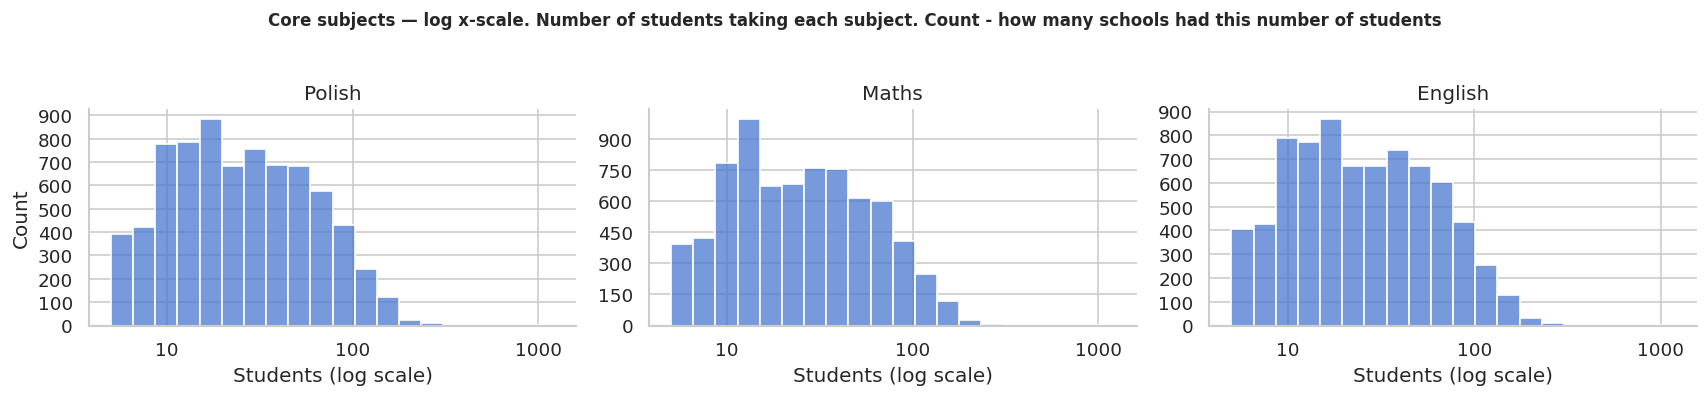

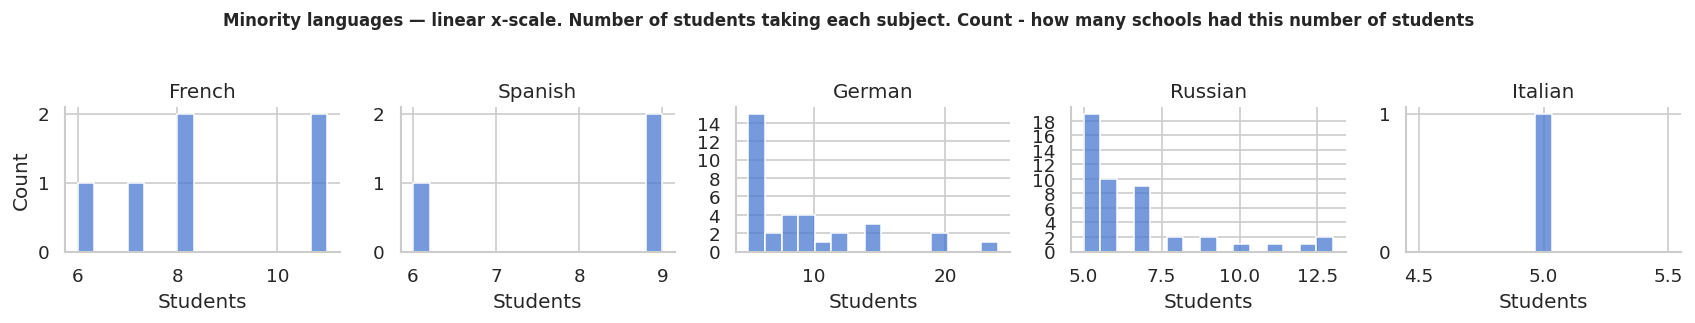


Minority languages — records with valid median data (n ≥ 5):


,School-year records,Median students,Max students
Subject,,,
French,6,8,11
Spanish,3,9,9
German,34,7,24
Russian,47,6,13
Italian,1,5,5


In [7]:
# ── Core subjects: log x-scale | Minority languages: linear x-scale ──────────
long_core = pd.concat([
    df.loc[df[f'median_{s}'].notna(), [f'n_{s}']]
    .rename(columns={f'n_{s}': 'Students'})
    .assign(Language=all_subjects_short[s])
    for s in core_short if f'n_{s}' in df.columns
]).dropna()
long_core['Language'] = pd.Categorical(
    long_core['Language'],
    categories=[all_subjects_short[s] for s in core_short],
    ordered=True,
)

long_min = pd.concat([
    df.loc[df[f'median_{s}'].notna(), [f'n_{s}']]
    .rename(columns={f'n_{s}': 'Students'})
    .assign(Language=all_subjects_short[s])
    for s in minority_short if f'n_{s}' in df.columns
]).dropna()
long_min['Language'] = pd.Categorical(
    long_min['Language'],
    categories=[all_subjects_short[s] for s in minority_short if f'n_{s}' in df.columns],
    ordered=True,
)

# Core — log x-scale
g1 = sns.FacetGrid(long_core, col='Language', col_wrap=3,
                   sharex=False, sharey=False, height=3.2, aspect=1.5)
g1.map(sns.histplot, 'Students', bins=20, log_scale=(True, False))
g1.set_titles('{col_name}')
g1.set_axis_labels('Students (log scale)', 'Count')
for ax in g1.axes.flat:
    ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))
    ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
g1.figure.suptitle('Core subjects — log x-scale. Number of students taking each subject. Count - how many schools had this number of students', fontsize=10, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

g = sns.FacetGrid(long_min, col='Language', col_wrap=5,
                  sharex=False, sharey=False, height=2.6, aspect=1.1)
g.map(sns.histplot, 'Students', bins=15)
g.set_titles('{col_name}')
g.set_axis_labels('Students', 'Count')
for ax in g.axes.flat:
    ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))
g.figure.suptitle('Minority languages — linear x-scale. Number of students taking each subject. Count - how many schools had this number of students', fontsize=10, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

# ── Summary table for minority languages (only records with valid median, i.e. n ≥ 5) ──
rows = []
for short in minority_short:
    col = f'n_{short}'
    if col not in df.columns:
        continue
    s = df.loc[df[f'median_{short}'].notna(), col].dropna()
    if s.empty:
        continue
    rows.append({
        'Subject':             all_subjects_short[short],
        'School-year records': len(s),
        'Median students':     int(s.median()),
        'Max students':        int(s.max()),
    })
print('\nMinority languages — records with valid median data (n ≥ 5):')
display(pd.DataFrame(rows).set_index('Subject'))

### Distribution of students count per school

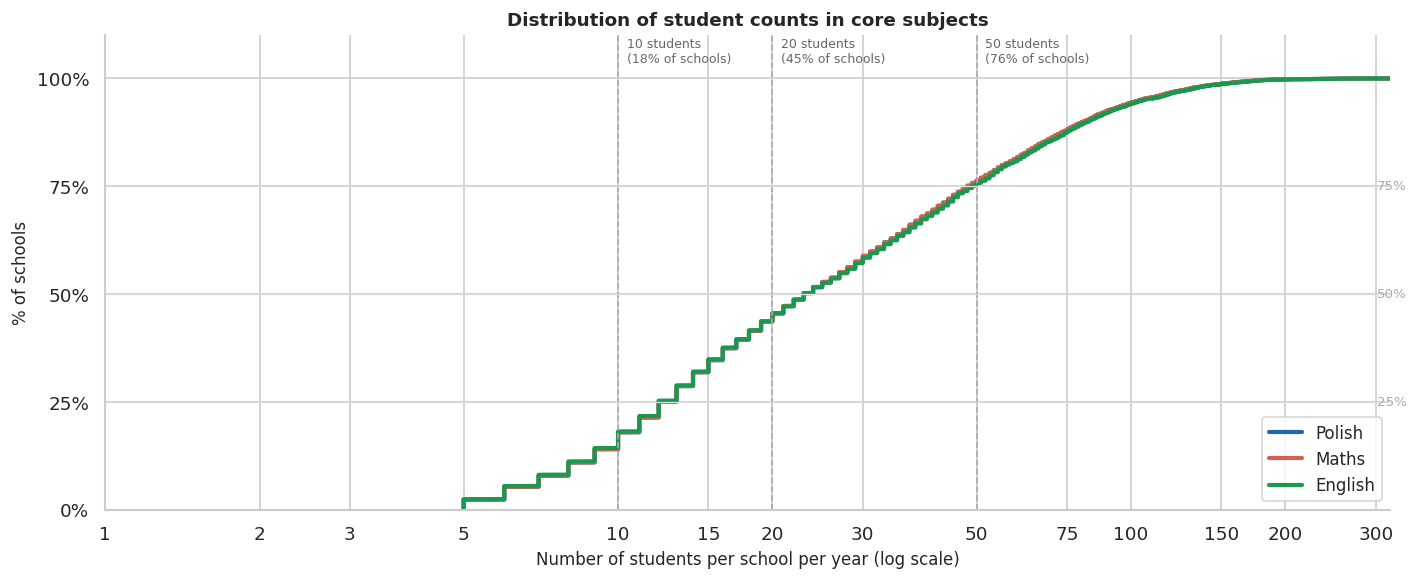

In [8]:
# ── ECDF for the 3 core subjects ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))

core_colors = ['#2166ac', '#d6604d', '#1a9850']
for short, color in zip(core_short, core_colors):
    col = f'n_{short}'
    if col not in df.columns:
        continue
    x = np.sort(df[col].dropna().values)
    y = np.arange(1, len(x) + 1) / len(x) * 100
    ax.plot(x, y, label=all_subjects_short[short], color=color, lw=2.5)

# Reference lines — percentages computed from actual n_polski distribution
_n_ref = df['n_polski'].dropna().values
for thresh in [10, 20, 50]:
    pct = ((_n_ref <= thresh).mean() * 100)
    ax.axvline(thresh, color='#aaa', ls='--', lw=1)
    ax.text(thresh * 1.04, 103,
            f'{thresh} students\n({pct:.0f}% of schools)',
            fontsize=7.5, color='#666', va='bottom')

for ref in [25, 50, 75]:
    ax.axhline(ref, color='#ddd', lw=0.8)
    ax.text(302, ref, f'{ref}%', fontsize=8, color='#aaa', va='center', ha='left')

ax.set_xscale('log')
ticks = [1, 2, 3, 5, 10, 15, 20, 30, 50, 75, 100, 150, 200, 300]
ax.set_xticks(ticks)
ax.get_xaxis().set_major_formatter(ticker.ScalarFormatter())
ax.set_xlim(1, 320)
ax.set_ylim(0, 110)
ax.set_yticks([0, 25, 50, 75, 100])
ax.yaxis.set_major_formatter(ticker.PercentFormatter(decimals=0))
ax.set_xlabel('Number of students per school per year (log scale)', fontsize=10)
ax.set_ylabel('% of schools', fontsize=10)
ax.set_title('Distribution of student counts in core subjects', fontsize=11, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

**Takeaway:** Almost half of all schools have no more than 20 students sitting any given exam in any given year.
For around one fifth of schools, this number is not more than 10. This matters a lot for how we measure quality (couple good/bad students can strongly affect school results).

## 3. Choosing the best per-year metric

### The problem with raw scores

The exam difficulty changes year to year. In 2021, the voivodeship median for Maths was **46%**;
in 2022 it jumped to **60%**. A school scoring 55% in both years looks stable,
but in 2021 it was 9 points *above* average and in 2022 it was 5 points *below* average.
Raw scores alone can't tell us how a school is doing relative to its peers.

### Candidate metrics

For each school in each year we can compute:

| Metric | Description |
|--------|-------------|
| `mean` | Average student score |
| `median` | Middle student's score (less sensitive to outliers) |
| `pct_mean` | Percentile rank of the mean among all schools that year |
| `pct_median` | Percentile rank of the median among all schools that year |
| `diff_median` | School median minus voivodeship median for that year |
| `pct_above_voivodeship` | Is the school above the voivodeship median? (1 or 0) |

### How we choose

We use **jackknife (leave-one-out) stability**: for a school with 5 years of data,
we compute the metric 5 times, each time leaving out one year. The more the result
changes, the less stable the metric — and a less stable metric means the score is
driven by luck (which year happened to be included) rather than real school quality.

We want the metric where the 5 estimates are *closest together*.

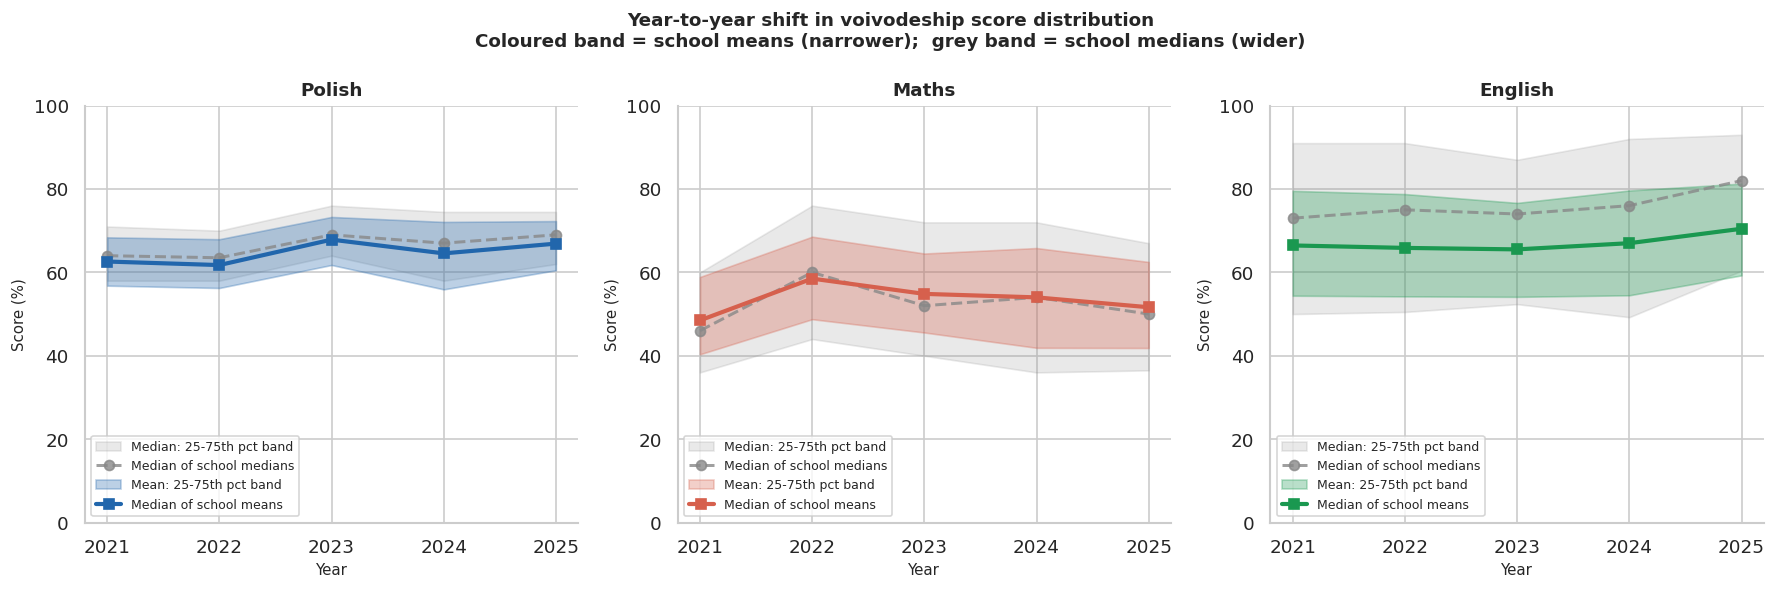

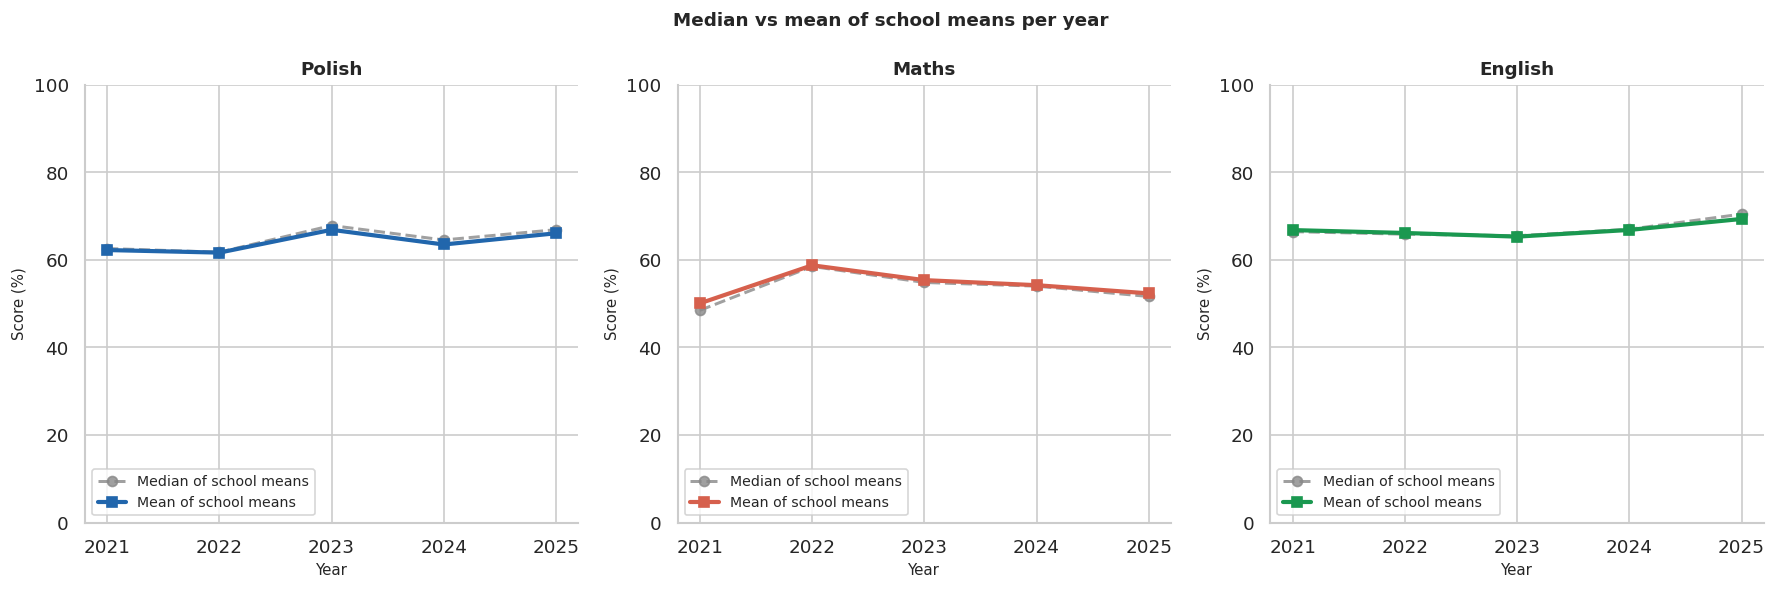

Median of school medians:


,Polish,Maths,English
year,,,
2021,64.0,46.0,73.0
2022,63.5,60.0,75.0
2023,69.0,52.0,74.0
2024,67.0,54.0,76.0
2025,69.0,50.0,82.0



Median of school means:


,Polish,Maths,English
year,,,
2021,62.6,48.5,66.5
2022,61.8,58.5,65.9
2023,67.9,54.8,65.5
2024,64.6,54.0,67.0
2025,66.9,51.6,70.5



Mean of school means:


,Polish,Maths,English
year,,,
2021,62.2,50.1,66.8
2022,61.7,58.8,66.1
2023,66.9,55.4,65.3
2024,63.5,54.2,66.8
2025,66.1,52.3,69.3



Year-to-year range (max - min across 5 years) -- smaller = more stable:


,Polish,Maths,English
Median of mediana range (pp),5.5,14.0,9.0
Mean of means range (pp),5.2,8.7,4.0


In [123]:
# Year-to-year voivodeship distribution: school medians (grey) vs school means (coloured)
yrs     = sorted(df['year'].unique())
n_years = len(yrs)

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=False)

for ax, subj in zip(axes, CORE_SUBJECTS):
    color = SUBJECT_COLORS[subj]

    grp_med  = df.groupby('year')[f'median_{subj}']
    grp_mean = df.groupby('year')[f'mean_{subj}']

    q25_med = grp_med.quantile(0.25).values
    q50_med = grp_med.quantile(0.50).values
    q75_med = grp_med.quantile(0.75).values

    q25_avg = grp_mean.quantile(0.25).values
    q50_avg = grp_mean.quantile(0.50).values
    q75_avg = grp_mean.quantile(0.75).values

    ax.fill_between(yrs, q25_med, q75_med, alpha=0.18, color='#888888',
                    label='Median: 25-75th pct band')
    ax.plot(yrs, q50_med, 'o--', lw=1.8, color='#888888', alpha=0.8,
            label='Median of school medians')
    ax.fill_between(yrs, q25_avg, q75_avg, alpha=0.30, color=color,
                    label='Mean: 25-75th pct band')
    ax.plot(yrs, q50_avg, 's-', lw=2.5, color=color,
            label='Median of school means')

    ax.set_title(SUBJECT_LABELS[subj], fontsize=11, fontweight='bold')
    ax.set_xlabel('Year', fontsize=9)
    ax.set_ylabel('Score (%)', fontsize=9)
    ax.set_xticks(yrs)
    ax.set_ylim(0, 100)
    ax.legend(fontsize=7.5, loc='lower left')
    ax.spines[['top', 'right']].set_visible(False)

fig.suptitle(
    'Year-to-year shift in voivodeship score distribution\n'
    'Coloured band = school means (narrower);  grey band = school medians (wider)',
    fontsize=11, fontweight='bold'
)
plt.tight_layout()
plt.show()
# Median of school means vs mean of school means
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=False)

for ax, subj in zip(axes, CORE_SUBJECTS):
    color = SUBJECT_COLORS[subj]
    grp_mean = df.groupby('year')[f'mean_{subj}']

    q50_avg  = grp_mean.quantile(0.50).values
    mean_avg = grp_mean.mean().values

    ax.plot(yrs, q50_avg, 'o--', lw=1.8, color='#888888', alpha=0.8,
            label='Median of school means')
    ax.plot(yrs, mean_avg, 's-', lw=2.5, color=color,
            label='Mean of school means')

    ax.set_title(SUBJECT_LABELS[subj], fontsize=11, fontweight='bold')
    ax.set_xlabel('Year', fontsize=9)
    ax.set_ylabel('Score (%)', fontsize=9)
    ax.set_xticks(yrs)
    ax.set_ylim(0, 100)
    ax.legend(fontsize=8.5, loc='lower left')
    ax.spines[['top', 'right']].set_visible(False)

fig.suptitle('Median vs mean of school means per year', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

print('Median of school medians:')
nat_med_table = pd.DataFrame({
    SUBJECT_LABELS[s]: df.groupby('year')[f'median_{s}'].median()
    for s in CORE_SUBJECTS
})
display(nat_med_table.round(1))

print('\nMedian of school means:')
nat_mean_table = pd.DataFrame({
    SUBJECT_LABELS[s]: df.groupby('year')[f'mean_{s}'].median()
    for s in CORE_SUBJECTS
})
display(nat_mean_table.round(1))

print('\nMean of school means:')
nat_mean_table = pd.DataFrame({
    SUBJECT_LABELS[s]: df.groupby('year')[f'mean_{s}'].mean()
    for s in CORE_SUBJECTS
})
display(nat_mean_table.round(1))

print(f'\nYear-to-year range (max - min across {n_years} years) -- smaller = more stable:')
med_rng = {SUBJECT_LABELS[s]: round(
    df.groupby('year')[f'median_{s}'].median().max()
    - df.groupby('year')[f'median_{s}'].median().min(), 1)
    for s in CORE_SUBJECTS}
avg_rng = {SUBJECT_LABELS[s]: round(
    df.groupby('year')[f'mean_{s}'].mean().max()
    - df.groupby('year')[f'mean_{s}'].mean().min(), 1)
    for s in CORE_SUBJECTS}
display(pd.DataFrame({'Median of mediana range (pp)': med_rng,
                      'Mean of means range (pp)':   avg_rng}).T)

### Why does the median jumps more than mean?

1. If we consider only school means as expected when exam is easy (Polish, English) typically bad students push the mean down so mean is below median.
With hard subjects like Math situation is opposite - middle student has lower score so good students push mean higher than median.
We also see that in years were Math exam got easier the difference decreased.
2. But why median which in some settings is more stable than mean, here jumps way more?

### Why does the voivodeship median of medians in Maths jumps 14 pp while the voivodeship median of means moves only 10 pp?

For Maths between 2021 and 2022, the voivodeship median of medians jumped from 46 to 60 (14 pp),
while the voivodeship median of means moved only from 48.5 to 58.5 (10 pp). What explains this 4 pp gap?

It's not random noise, and it's not just quantization (school medians come in 2 pp steps,
which can explain at most 1-2 pp of the jump). The real explanation requires looking
at how *individual* schools moved between the two years.

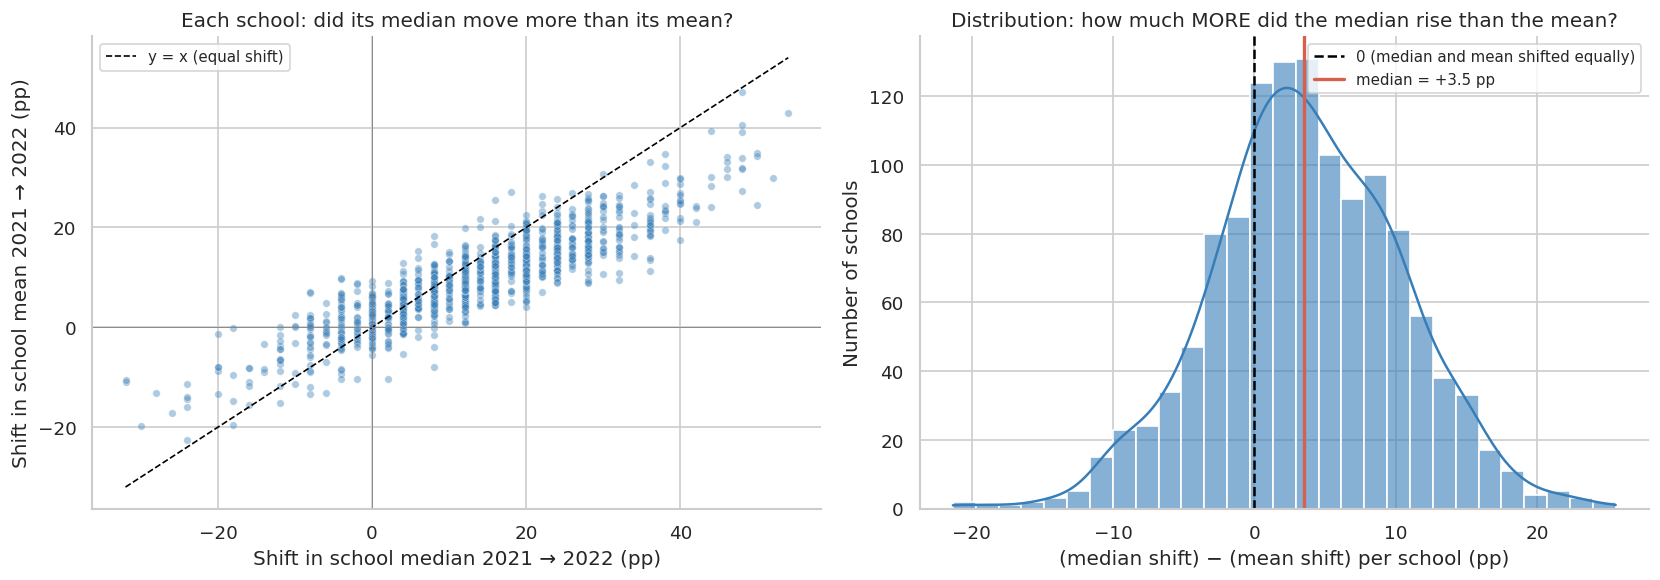

Schools tracked across 2021→2022: 1,247
Median shift in school medians: +14.0 pp
Median shift in school means:   +10.0 pp
Median of (median_shift − mean_shift): +3.5 pp
% schools where median rose more than mean: 71%


In [128]:
# Track the SAME schools across 2021 and 2022 — how much did each shift?
sub_2021 = df[df['year'] == 2021].set_index('rspo')
sub_2022 = df[df['year'] == 2022].set_index('rspo')
common = sub_2021.index.intersection(sub_2022.index)

shift_med = sub_2022.loc[common, 'median_matematyka'] - sub_2021.loc[common, 'median_matematyka']
shift_avg = sub_2022.loc[common, 'mean_matematyka']   - sub_2021.loc[common, 'mean_matematyka']
shift_math_df = pd.DataFrame({'shift_med': shift_med, 'shift_avg': shift_avg})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Scatter: shift in median vs shift in mean ---
ax = axes[0]
sns.scatterplot(data=shift_math_df, x='shift_med', y='shift_avg',
                ax=ax, alpha=0.4, s=20, color='#377eb8')

# Reference line y = x (where median and mean shifts would be equal)
lo = min(shift_math_df.min().min(), -5)
hi = max(shift_math_df.max().max(), 5)
ax.plot([lo, hi], [lo, hi], color='black', ls='--', lw=1,
        label='y = x (equal shift)')

ax.axhline(0, color='gray', lw=0.5)
ax.axvline(0, color='gray', lw=0.5)
ax.set_xlabel('Shift in school median 2021 → 2022 (pp)')
ax.set_ylabel('Shift in school mean 2021 → 2022 (pp)')
ax.set_title('Each school: did its median move more than its mean?')
ax.legend(loc='upper left', fontsize=9)
ax.spines[['top', 'right']].set_visible(False)

# Most points sit BELOW the y=x line → median rose more than the mean

# --- Histogram: median shift minus mean shift ---
ax = axes[1]
diff = shift_med - shift_avg
sns.histplot(diff, kde=True, ax=ax, color='#377eb8', alpha=0.6)
ax.axvline(0, color='black', ls='--', lw=1.5,
           label='0 (median and mean shifted equally)')
ax.axvline(diff.median(), color='#d6604d', lw=2,
           label=f'median = {diff.median():+.1f} pp')
ax.set_xlabel('(median shift) − (mean shift) per school (pp)')
ax.set_ylabel('Number of schools')
ax.set_title('Distribution: how much MORE did the median rise than the mean?')
ax.legend(loc='upper right', fontsize=9)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

# Numeric summary
print(f'Schools tracked across 2021→2022: {len(common):,}')
print(f'Median shift in school medians: {shift_med.median():+.1f} pp')
print(f'Median shift in school means:   {shift_avg.median():+.1f} pp')
print(f'Median of (median_shift − mean_shift): {(shift_med - shift_avg).median():+.1f} pp')
print(f'% schools where median rose more than mean: {((shift_med - shift_avg) > 0).mean()*100:.0f}%')

### How did individual schools move 2021 → 2022?

**Left:** Each dot is one school. The X-axis is how much that school's median moved
between 2021 and 2022. The Y-axis is how much its mean moved. If both metrics
captured the same thing, dots would sit on the dashed y = x line.

The dots sit consistently *below* the line — meaning for almost every school, the
median rose **more** than the mean. The exam got easier, but the median student
benefited more than the average student.

**Right:** The same fact shown as a distribution. We plot (median shift) − (mean shift)
for each school. If this difference were near zero, the two metrics would behave
similarly. Instead the distribution is clearly shifted to the right of zero —
the median rose about 4 pp more than the mean for the typical school.

**Why does this happen?**

The mean averages over the whole class, including students at both extremes.
When the exam got easier, the strong students were already near 90–100% — they
couldn't gain as much (ceiling effect). The mean reflects this dampening.

The median is the score of the *middle* student. When the difficulty shifts,
this middle student's score moves by the full amount of the shift, because they
weren't pressed against the ceiling. So the median captures the shift in full,
the mean captures it after ceiling/floor effects dampen the extremes.

**Implication for the metric:**

The voivodeship mean is a more *linear* function of exam difficulty than the
voivodeship median — it absorbs ceiling and floor effects proportionally.
Subtracting the voivodeship mean from each school's mean (`diff_avg`) gives a
cleaner residual signal about that school's performance, relative to the
voivodeship in that year. Subtracting the voivodeship median (`diff_med`) leaves
residuals contaminated by the non-linear response of the median to difficulty
shifts. This is one more reason `diff_avg` beats `diff_med` in LOO stability.

In [14]:
# Compute voivodeship median per year per subject (used for diff_median)
nat_median = {}
for short in core_short:
    nat_median[short] = df.groupby('year')[f'median_{short}'].median()
    df[f'nat_median_{short}'] = df['year'].map(nat_median[short])
    df[f'diff_median_{short}'] = df[f'median_{short}'] - df[f'nat_median_{short}']

# Compute percentile ranks within each year for mean and median
for short in core_short:
    for metric in ['median', 'mean']:
        col_in  = f'{metric}_{short}'
        col_out = f'pct_{metric}_{short}'
        df[col_out] = df.groupby('year')[col_in].transform(
            lambda x: stats.rankdata(x.fillna(x.median()), method='average') / len(x) * 100
        )

print('Voivodeship median per year:')
nat_df = pd.DataFrame({SUBJECT_LABELS[s]: nat_median[s] for s in core_short})
nat_df.index.name = 'year'
display(nat_df.round(1))
print('\nNote: Maths swings 14 pp between 2021 and 2022 — a school with a constant raw score')
print('would look good in 2021 and mediocre in 2022 for no reason related to the school.')

Voivodeship median per year:


,Polish,Maths,English
year,,,
2021,64.0,46.0,73.0
2022,63.5,60.0,75.0
2023,69.0,52.0,74.0
2024,67.0,54.0,76.0
2025,69.0,50.0,82.0



Note: Maths swings 14 pp between 2021 and 2022 — a school with a constant raw score
would look good in 2021 and mediocre in 2022 for no reason related to the school.


In [15]:
# ── Jackknife LOO stability ───────────────────────────────────────────────────
# Only use schools with data in at least 3 years
year_count = df.groupby('rspo')['year'].nunique()
df_multi = df[df['rspo'].isin(year_count[year_count >= 3].index)].copy()

METRIC_COLS = {
    'mean':             lambda s: f'mean_{s}',
    'median':           lambda s: f'median_{s}',
    'pct_mean':         lambda s: f'pct_mean_{s}',
    'pct_median':       lambda s: f'pct_median_{s}',
    'diff_median':      lambda s: f'diff_median_{s}',
    'pct_above_nat':    None,  # computed inline
}

loo_records = []

for rspo, grp in df_multi.groupby('rspo'):
    grp = grp.sort_values('year').reset_index(drop=True)
    k = len(grp)

    for short in core_short:
        n_vals = grp[f'n_{short}'].values
        if np.any(np.isnan(n_vals)) or n_vals.sum() == 0:
            continue

        loo_results = {m: [] for m in METRIC_COLS}

        for lo in range(k):
            mask  = np.ones(k, dtype=bool); mask[lo] = False
            n_sub = n_vals[mask]
            tot_n = n_sub.sum()
            if tot_n == 0:
                continue

            for metric_name, col_fn in METRIC_COLS.items():
                if metric_name == 'pct_above_nat':
                    vals = (grp[f'diff_median_{short}'].values[mask] > 0).astype(float)
                else:
                    col = col_fn(short)
                    vals = grp[col].values[mask]
                if np.any(np.isnan(vals)):
                    continue
                loo_results[metric_name].append(
                    (n_sub * vals).sum() / tot_n  # weighted mean across remaining years
                )

        row = {'rspo': rspo, 'subject': short, 'mean_n': n_vals.mean(), 'n_years': k}
        for metric_name, values in loo_results.items():
            if len(values) >= 2:
                row[f'loo_std_{metric_name}'] = np.std(values)
        loo_records.append(row)

loo = pd.DataFrame(loo_records)

# Size bins
loo['size_bin'] = pd.cut(
    loo['mean_n'],
    bins=[0, 9, 19, 49, 99, 9999],
    labels=['1–9', '10–19', '20–49', '50–99', '100+']
)

print(f'LOO computed for {len(loo):,} school-subject pairs')

LOO computed for 4,713 school-subject pairs


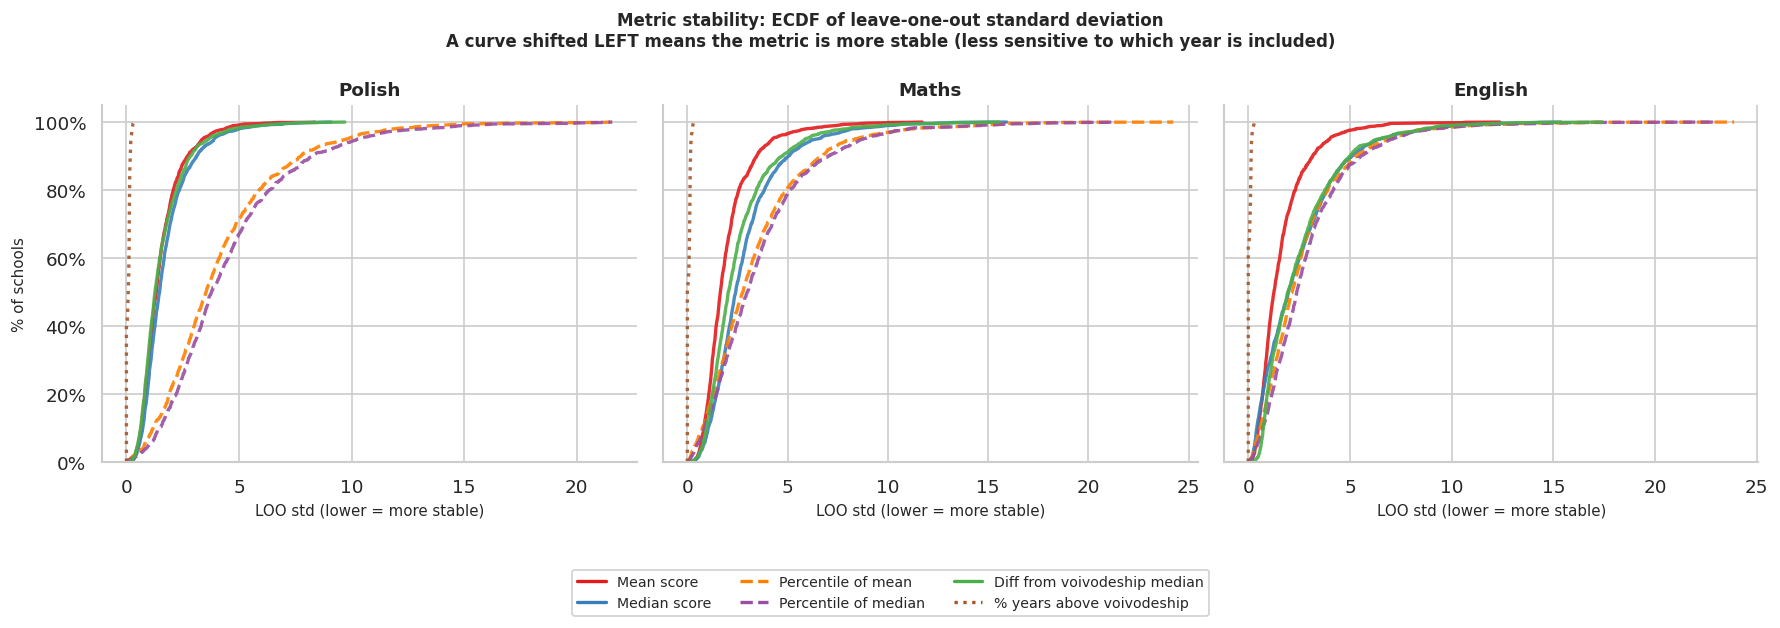

In [16]:
# ── Plot: ECDF of LOO std for each metric, for Maths (most variable) ──────────
loo_std_cols = [c for c in loo.columns if c.startswith('loo_std_')]
metric_display = {
    'loo_std_mean':          ('Mean score',              '#e41a1c', '-'),
    'loo_std_median':        ('Median score',            '#377eb8', '-'),
    'loo_std_pct_mean':      ('Percentile of mean',      '#ff7f00', '--'),
    'loo_std_pct_median':    ('Percentile of median',    '#984ea3', '--'),
    'loo_std_diff_median':   ('Diff from voivodeship median','#4daf4a', '-'),
    'loo_std_pct_above_nat': ('% years above voivodeship',  '#a65628', ':'),
}

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

for ax, short in zip(axes, core_short):
    sub = loo[loo['subject'] == short]
    for col, (label, color, ls) in metric_display.items():
        if col not in sub.columns:
            continue
        x = np.sort(sub[col].dropna().values)
        y = np.arange(1, len(x) + 1) / len(x) * 100
        ax.plot(x, y, label=label, color=color, lw=2, ls=ls, alpha=0.9)

    ax.set_title(SUBJECT_LABELS[short], fontsize=11, fontweight='bold')
    ax.set_xlabel('LOO std (lower = more stable)', fontsize=9)
    ax.spines[['top', 'right']].set_visible(False)

axes[0].set_ylabel('% of schools', fontsize=9)
axes[0].yaxis.set_major_formatter(ticker.PercentFormatter(decimals=0))
axes[0].set_ylim(0, 105)

handles = [mlines.Line2D([], [], color=c, lw=2, ls=ls, label=lbl)
           for lbl, c, ls in metric_display.values()]
fig.legend(handles=handles, loc='lower center', ncol=3, fontsize=8.5,
           framealpha=0.9, bbox_to_anchor=(0.5, -0.04))

fig.suptitle(
    'Metric stability: ECDF of leave-one-out standard deviation\n'
    'A curve shifted LEFT means the metric is more stable (less sensitive to which year is included)',
    fontsize=10, fontweight='bold'
)
plt.tight_layout(rect=[0, 0.10, 1, 1])
plt.show()

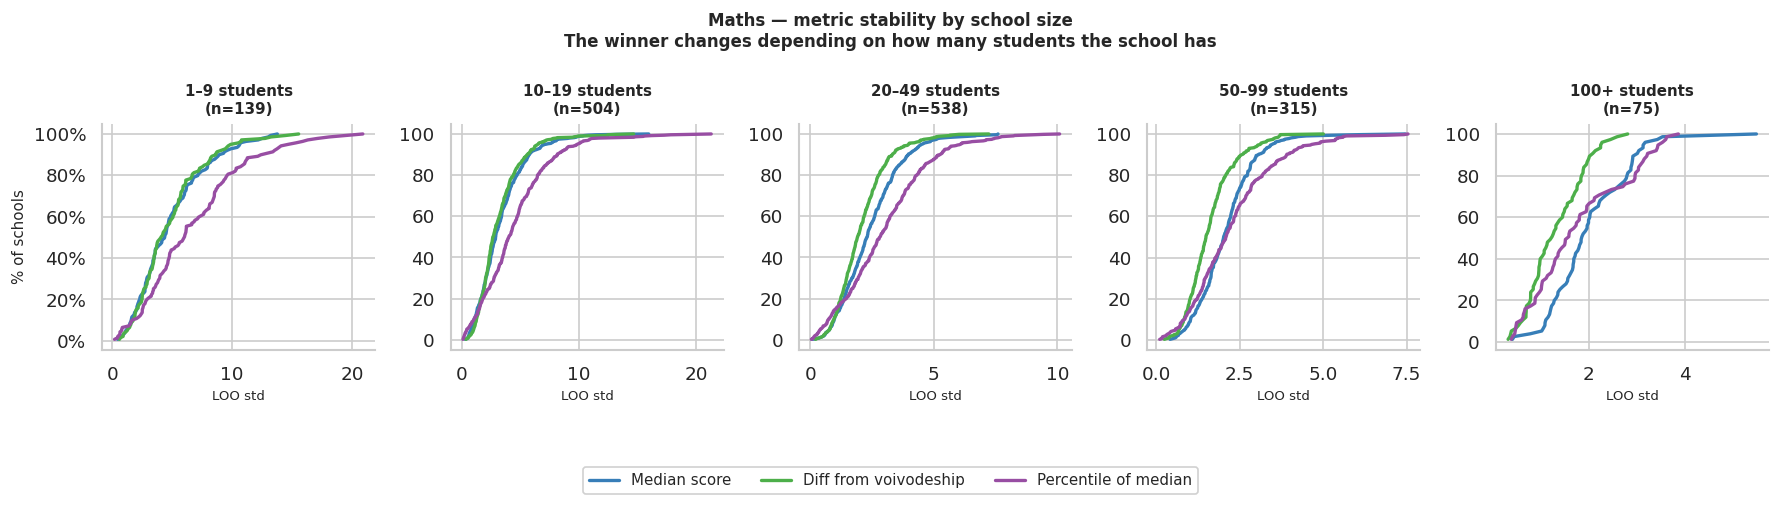

In [17]:
# ── Same, split by school size ────────────────────────────────────────────────
# Show Maths only (most variable; result pattern is the same for other subjects)
mat_loo = loo[loo['subject'] == 'matematyka'].copy()

SIZE_BINS = ['1–9', '10–19', '20–49', '50–99', '100+']
TOP_METRICS = ['loo_std_median', 'loo_std_diff_median', 'loo_std_pct_median']
TOP_COLORS  = ['#377eb8', '#4daf4a', '#984ea3']
TOP_LABELS  = ['Median score', 'Diff from voivodeship', 'Percentile of median']

fig, axes = plt.subplots(1, len(SIZE_BINS), figsize=(15, 4), sharey=False)

for ax, size_bin in zip(axes, SIZE_BINS):
    sub = mat_loo[mat_loo['size_bin'] == size_bin]
    n_schools = len(sub)
    for col, color, label in zip(TOP_METRICS, TOP_COLORS, TOP_LABELS):
        if col not in sub.columns:
            continue
        x = np.sort(sub[col].dropna().values)
        y = np.arange(1, len(x) + 1) / len(x) * 100
        ax.plot(x, y, color=color, lw=2, label=label)

    ax.set_title(f'{size_bin} students\n(n={n_schools})', fontsize=9, fontweight='bold')
    ax.set_xlabel('LOO std', fontsize=8)
    ax.spines[['top', 'right']].set_visible(False)

axes[0].set_ylabel('% of schools', fontsize=9)
axes[0].yaxis.set_major_formatter(ticker.PercentFormatter(decimals=0))

handles = [mlines.Line2D([], [], color=c, lw=2, label=lbl)
           for c, lbl in zip(TOP_COLORS, TOP_LABELS)]
fig.legend(handles=handles, loc='lower center', ncol=3, fontsize=9,
           framealpha=0.9, bbox_to_anchor=(0.5, -0.04))

fig.suptitle(
    'Maths — metric stability by school size\n'
    'The winner changes depending on how many students the school has',
    fontsize=10, fontweight='bold'
)
plt.tight_layout(rect=[0, 0.12, 1, 1])
plt.show()

In [18]:
# ── Summary table: median LOO std per size bin ────────────────────────────────
agg = (
    mat_loo.groupby('size_bin', observed=True)[TOP_METRICS]
    .median()
    .rename(columns=dict(zip(TOP_METRICS, TOP_LABELS)))
    .round(2)
)
print('Median LOO std for Maths — lower is better:')
display(agg.style.highlight_min(axis=1, color='#c6efce')
             .set_caption('Green = most stable metric for that school size'))

Median LOO std for Maths — lower is better:


,Median score,Diff from voivodeship,Percentile of median
size_bin,,,
1–9,4.370000,4.080000,6.020000
10–19,2.890000,2.660000,4.020000
20–49,2.310000,1.910000,2.830000
50–99,2.020000,1.490000,2.090000
100+,1.850000,1.230000,1.580000


**Finding:** `diff_median` (school median minus the voivodeship median for that year)
is the most stable metric for schools with **≥ 10 students**,
which covers about 75% of schools.

For very small schools (< 10 students) the raw median score is marginally more stable,
but the difference is tiny (< 0.15 pp). We will use `diff_median` for all schools
because it removes the year-difficulty bias — a school that happened to miss
the difficult 2021 Maths exam (voivodeship median 46 pp vs. 60 pp in 2022)
would get a **2.9 pp bonus** with raw scores but only **0.16 pp** with `diff_median`.

## 4. Aggregating across years

We have up to 5 years of data per school. We need to combine them into one number.

Three natural options:
- **Weighted mean** — weight each year by the number of students sitting the exam
- **Median of years** — take the middle year's result (ignores how many students)
- **Trimmed mean** — drop the best and worst year, average the rest

We apply the same jackknife test: which aggregation gives the most stable
school score when we drop one year?

In [19]:
# For schools with 5 years of data: LOO stability of 3 aggregation methods
year_count_5 = df.groupby('rspo')['year'].nunique()
df5 = df[df['rspo'].isin(year_count_5[year_count_5 == 5].index)].copy()

agg_records = []

for rspo, grp in df5.groupby('rspo'):
    grp = grp.sort_values('year').reset_index(drop=True)

    for short in core_short:
        n_vals   = grp[f'n_{short}'].values
        diff_vals= grp[f'diff_median_{short}'].values
        if np.any(np.isnan(n_vals)) or np.any(np.isnan(diff_vals)):
            continue

        loo_wmean, loo_median, loo_trimmed = [], [], []

        for lo in range(5):
            mask  = np.ones(5, dtype=bool); mask[lo] = False
            n_sub = n_vals[mask]
            d_sub = diff_vals[mask]
            tot_n = n_sub.sum()
            if tot_n == 0:
                continue
            loo_wmean.append((n_sub * d_sub).sum() / tot_n)
            loo_median.append(np.median(d_sub))
            # trimmed: with 4 values, drop min and max (keep middle 2)
            sorted_d = np.sort(d_sub)
            loo_trimmed.append(sorted_d[1:3].mean())

        if len(loo_wmean) >= 4:
            agg_records.append({
                'rspo':            rspo,
                'subject':         short,
                'mean_n':          n_vals.mean(),
                'std_wmean':       np.std(loo_wmean),
                'std_median_yrs':  np.std(loo_median),
                'std_trimmed':     np.std(loo_trimmed),
            })

agg_loo = pd.DataFrame(agg_records)
agg_loo['size_bin'] = pd.cut(
    agg_loo['mean_n'],
    bins=[0, 9, 19, 49, 99, 9999],
    labels=['1–9', '10–19', '20–49', '50–99', '100+']
)

agg_summary = (
    agg_loo.groupby('size_bin', observed=True)[['std_wmean', 'std_median_yrs', 'std_trimmed']]
    .median()
    .rename(columns={
        'std_wmean':      'Weighted mean',
        'std_median_yrs': 'Median of years',
        'std_trimmed':    'Trimmed mean',
    })
    .round(3)
)
print('Median LOO std for aggregation methods (diff_median as input), all subjects:')
display(agg_summary.style.highlight_min(axis=1, color='#c6efce')
                   .set_caption('Green = most stable aggregation for that school size'))

Median LOO std for aggregation methods (diff_median as input), all subjects:


,Weighted mean,Median of years,Trimmed mean
size_bin,,,
1–9,2.818000,3.115000,3.115000
10–19,2.101000,2.015000,2.015000
20–49,1.535000,1.568000,1.568000
50–99,1.137000,1.225000,1.225000
100+,0.869000,0.894000,0.894000


**Finding:** Weighted mean (weighting each year by number of students)
is the most stable or tied-most-stable for all school sizes.
It also has the best intuitive justification: a year where 50 students sat the exam
should count more than a year where only 5 did.

**Final per-subject score formula:**
```
score(school, subject) = Σ(n_year × diff_year) / Σ(n_year)

where diff_year = school_median_year − voivodeship_median_year
```
This gives a number in percentage points: positive means above average for the country,
negative means below average, zero means exactly at the voivodeship median.

In [20]:
# ── Compute final per-subject score for every school ──────────────────────────
score_records = []

for rspo, grp in df.groupby('rspo'):
    row = {'rspo': rspo}
    row['school_name'] = grp['school_name'].iloc[0]
    row['is_public']   = grp['is_public'].iloc[0]
    row['n_years']     = grp['year'].nunique()
    row['years']       = sorted(grp['year'].unique().tolist())

    for short in core_short:
        n_vals   = pd.to_numeric(grp[f'n_{short}'], errors='coerce')
        diff_vals= pd.to_numeric(grp[f'diff_median_{short}'], errors='coerce')
        valid    = n_vals.notna() & diff_vals.notna() & (n_vals > 0)
        if valid.sum() == 0:
            continue
        n_v = n_vals[valid].values
        d_v = diff_vals[valid].values
        tot_n = n_v.sum()
        row[f'score_{short}']   = (n_v * d_v).sum() / tot_n
        row[f'n_total_{short}'] = int(tot_n)
        row[f'n_years_{short}'] = int(valid.sum())

    score_records.append(row)

scores = pd.DataFrame(score_records)
scores = scores.dropna(subset=[f'score_{s}' for s in core_short])

# Add percentile ranks (used for the map colour)
for short in core_short:
    scores[f'pct_{short}'] = (
        stats.rankdata(scores[f'score_{short}'], method='average') / len(scores) * 100
    )

# Sigma per subject (for colour scale)
sigma = {short: scores[f'score_{short}'].std() for short in core_short}
print('Sigma per subject (used for colour saturation thresholds):')
for short in core_short:
    subj_name = SUBJECT_LABELS.get(short, short)
    print(f'  {subj_name:10s}: σ = {sigma[short]:.1f} pp   \'saturate\' at ±{1.5*sigma[short]:.0f} pp')

print(f'\nSchools with scores: {len(scores):,}')

Sigma per subject (used for colour saturation thresholds):
  Polish    : σ = 9.5 pp   'saturate' at ±14 pp
  Maths     : σ = 18.1 pp   'saturate' at ±27 pp
  English   : σ = 20.8 pp   'saturate' at ±31 pp

Schools with scores: 1,720


## 5. Which schools are consistently at the top?

Because individual years are noisy, we want to check that the top schools
are not just lucky — they should appear at the top across *multiple* LOO folds.

For each school we compute: how often does it appear in the top N
when we drop one year at a time? A school that is *always* in the top 30
is more trustworthy than one that is there only when one particular year is included.

In [21]:
# Jackknife stability of school ranking (Maths, schools with 5 years)
TOP_N_LIST = [5, 10, 30, 50]

def loo_scores(rspo_grp_iter, short: str) -> dict:
    """Return {rspo: [score_loo_0, score_loo_1, ...]} for all schools."""
    result = {}
    for rspo, grp in rspo_grp_iter:
        grp = grp.sort_values('year').reset_index(drop=True)
        n_vals   = grp[f'n_{short}'].values
        diff_vals= grp[f'diff_median_{short}'].values
        if np.any(np.isnan(n_vals)) or np.any(np.isnan(diff_vals)):
            continue
        k = len(grp)
        loos = []
        for lo in range(k):
            mask  = np.ones(k, dtype=bool); mask[lo] = False
            n_sub = n_vals[mask]; tot_n = n_sub.sum()
            if tot_n == 0: continue
            loos.append((n_sub * diff_vals[mask]).sum() / tot_n)
        if loos:
            result[rspo] = loos
    return result


short = 'matematyka'  # show for Maths; pattern is similar for other subjects
loo_vals = loo_scores(df5.groupby('rspo'), short)

# For each LOO fold, rank all schools and record top-N membership
n_folds = 5
all_rspo = list(loo_vals.keys())

# Matrix: rows=schools, cols=folds, value=score
fold_matrix = pd.DataFrame(
    {rspo: {f: vals[f] if f < len(vals) else np.nan for f in range(n_folds)}
     for rspo, vals in loo_vals.items()}
).T  # shape: (n_schools, 5)

consistency_rows = []
name_lu = df5.groupby('rspo')['school_name'].first()

for rspo in fold_matrix.index:
    row = {'rspo': rspo, 'school_name': name_lu.get(rspo, '?')}
    full_score = fold_matrix.loc[rspo].mean()  # mean across LOO folds ≈ full score
    row['mean_score'] = full_score
    for top_n in TOP_N_LIST:
        count_in_top = 0
        for fold in range(n_folds):
            fold_scores = fold_matrix[fold].dropna()
            rank = (fold_scores > fold_matrix.loc[rspo, fold]).sum() + 1
            if rank <= top_n:
                count_in_top += 1
        row[f'in_top_{top_n}_of_{n_folds}'] = count_in_top
    consistency_rows.append(row)

consistency = pd.DataFrame(consistency_rows).sort_values('mean_score', ascending=False)

print(f'Schools consistently in the top (Maths, schools with 5 years of data):')
display(
    consistency.head(40)[[
        'school_name', 'mean_score',
        f'in_top_5_of_{n_folds}', f'in_top_10_of_{n_folds}',
        f'in_top_30_of_{n_folds}', f'in_top_50_of_{n_folds}',
    ]].rename(columns={
        'mean_score':                'Avg score (pp above voivodeship)',
        f'in_top_5_of_{n_folds}':   f'In top 5 / {n_folds} folds',
        f'in_top_10_of_{n_folds}':  f'In top 10 / {n_folds} folds',
        f'in_top_30_of_{n_folds}':  f'In top 30 / {n_folds} folds',
        f'in_top_50_of_{n_folds}':  f'In top 50 / {n_folds} folds',
    }).style.background_gradient(cmap='Greens', subset=[f'In top 5 / {n_folds} folds',
                                                         f'In top 10 / {n_folds} folds'])
)

Schools consistently in the top (Maths, schools with 5 years of data):


,school_name,Avg score (pp above voivodeship),In top 5 / 5 folds,In top 10 / 5 folds,In top 30 / 5 folds,In top 50 / 5 folds
1063,"SZKOŁA PODSTAWOWA PRZY SPOŁECZNYM LICEUM OGÓLNOKSZTAŁCĄCYM NR 4 IM. BATALIONU AK ""PARASOL""",43.591733,5,5,5,5
327,"PRYWATNA SZKOŁA PODSTAWOWA NR 81 FUNDACJI ""RODZICE DZIECIOM""",43.404227,5,5,5,5
244,PRYWATNA SZKOŁA PODSTAWOWA NR 6 SIÓSTR NIEPOKALANEK IM. BŁ. M. MARCELINY DAROWSKIEJ,43.369818,5,5,5,5
489,SZKOŁA PODSTAWOWA NR 3 PRZYMIERZA RODZIN IM. BŁOGOSŁAWIONEGO KS. JERZEGO POPIEŁUSZKI,42.674575,2,5,5,5
336,PRYWATNA SZKOŁA PODSTAWOWA NR 92,42.651022,3,5,5,5
347,PRYWATNA SZKOŁA PODSTAWOWA NR 51 IM. JANA BRZECHWY,42.623601,2,5,5,5
242,SPOŁECZNA SZKOŁA PODSTAWOWA NR 10 IM.KARDYNAŁA STEFANA WYSZYŃSKIEGO SPOŁECZNEGO TOWARZYSTWA OŚWIATOWEGO,42.186227,1,4,5,5
315,"NIEPUBLICZNA SZKOŁA PODSTAWOWA NR 47 IM. ROBERTA SCHUMANA FUNDACJI ""PRIMUS""",41.742176,0,4,5,5
338,SPOŁECZNA SZKOŁA PODSTAWOWA INTEGRACYJNA NR 100 SPOŁECZNEGO TOWARZYSTWA OŚWIATOWEGO,41.702871,0,2,5,5
305,SPOŁECZNA SZKOŁA PODSTAWOWA NR 16 SPOŁECZNEGOTOWARZYSTWA OŚWIATOWEGO,41.674884,1,2,5,5


## 6. Combining all three subjects

A school could score well in Maths but poorly in Polish. How do we combine
the three subject scores into a single number for the map?

First, we check how correlated the three subjects are.
If they are highly correlated, the choice of combination method barely matters.
If they are independent, we need to be careful.

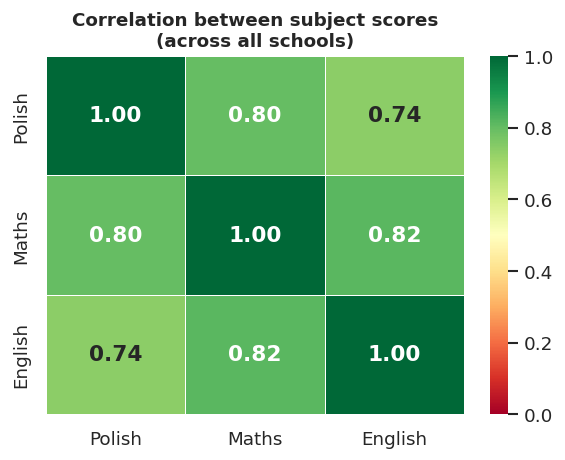


Spearman rank correlation (more robust to outliers):
         Polish  Maths  English
Polish     1.00   0.82     0.77
Maths      0.82   1.00     0.83
English    0.77   0.83     1.00


In [22]:
# ── Subject correlation ───────────────────────────────────────────────────────
score_cols = [f'score_{s}' for s in core_short]
corr = scores[score_cols].rename(
    columns={f'score_{s}': SUBJECT_LABELS.get(s, s) for s in core_short}
).corr()

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    corr, annot=True, fmt='.2f', cmap='RdYlGn',
    vmin=0, vmax=1, linewidths=0.5, ax=ax,
    annot_kws={'size': 13, 'weight': 'bold'}
)
ax.set_title('Correlation between subject scores\n(across all schools)', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nSpearman rank correlation (more robust to outliers):')
print(scores[score_cols].rename(
    columns={f'score_{s}': SUBJECT_LABELS.get(s, s) for s in core_short}
).corr(method='spearman').round(2))

Schools good in all 3 subjects (≥60th percentile each): 485
  of which public:   328
  of which private:  157


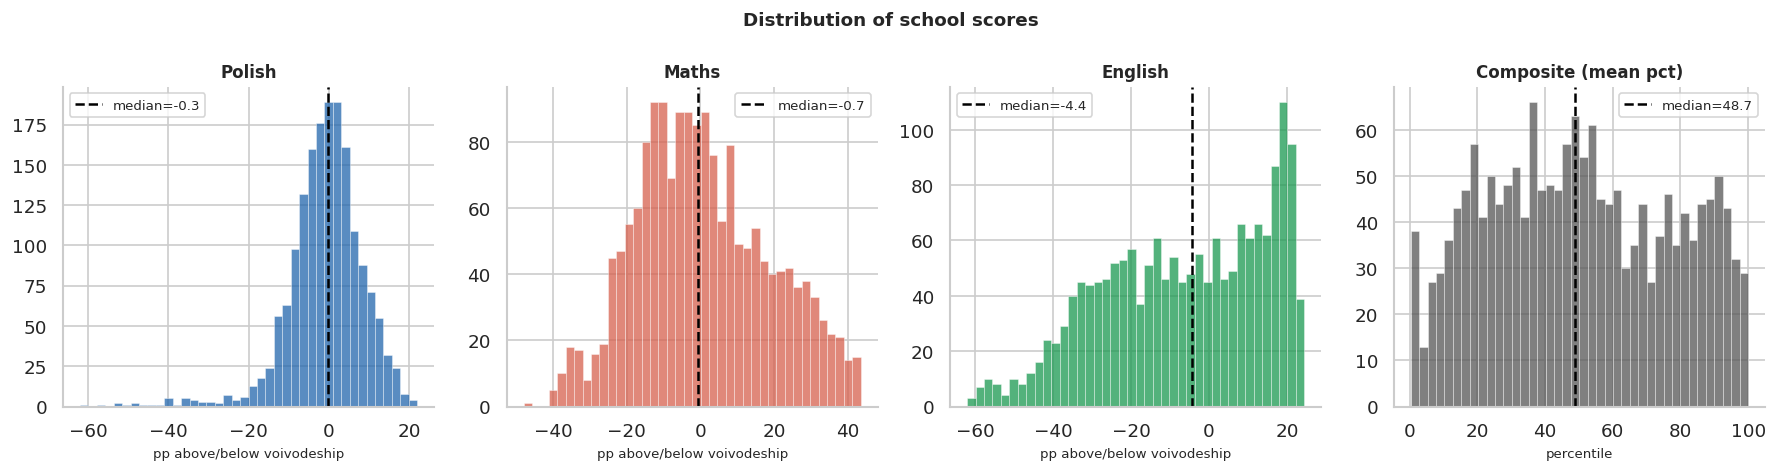

In [23]:
# ── Composite score: mean of per-subject percentiles ─────────────────────────
scores['composite_pct'] = scores[[f'pct_{s}' for s in core_short]].mean(axis=1)

scores['good_in_all_3'] = (
    (scores['pct_polski']    >= 60) &
    (scores['pct_matematyka']>= 60) &
    (scores['pct_angielski'] >= 60)
)

print(f'Schools good in all 3 subjects (≥60th percentile each): {scores["good_in_all_3"].sum()}')
print(f'  of which public:   {(scores["good_in_all_3"] & (scores["is_public"]=="Tak")).sum()}')
print(f'  of which private:  {(scores["good_in_all_3"] & (scores["is_public"]=="Nie")).sum()}')

fig, axes = plt.subplots(1, 4, figsize=(15, 4))

subjects_to_plot = [
    (f'score_{s}', SUBJECT_LABELS.get(s, s), SUBJECT_COLORS[s])
    for s in core_short
]
subjects_to_plot.append(('composite_pct', 'Composite (mean pct)', '#555555'))

for ax, (col, label, color) in zip(axes, subjects_to_plot):
    data = scores[col].dropna()
    ax.hist(data, bins=40, color=color, alpha=0.75, edgecolor='white', lw=0.3)
    ax.axvline(data.median(), color='black', lw=1.5, ls='--', label=f'median={data.median():.1f}')
    ax.set_title(label, fontsize=10, fontweight='bold')
    ax.set_xlabel('pp above/below voivodeship' if 'score' in col else 'percentile', fontsize=8)
    ax.legend(fontsize=8)
    ax.spines[['top', 'right']].set_visible(False)

fig.suptitle('Distribution of school scores', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Final metric definition

Based on the analysis above, here is the metric used for the school quality map.

### Per-subject score

```
diff_year(school, subject, year) =
    median_score(school, subject, year) − voivodeship_median(subject, year)

score(school, subject) =
    Σ_year [ n_students(year) × diff_year ] / Σ_year [ n_students(year) ]
```

This gives a number in percentage points:
- **+10 pp** means the middle student at this school scores 10 points above
  the middle student voivodeshiply, averaged over all available years.
- **−5 pp** means the school is below average by 5 points.

### Why this metric?

1. **Difference from voivodeship median** removes the year-difficulty effect
   (the 14 pp swing in Maths difficulty between 2021 and 2022 is neutralised).
2. **Median** is preferred over mean because outlier students
   (one gifted or one struggling child) affect the mean more than the median.
3. **Weighted by student count** means a year with 50 students carries
   more weight than a year with 5, which is statistically correct.
4. The metric is **not a percentile** — a school 10 pp above average gets that
   number regardless of whether 300 or 3 other schools are also around that level.
   Percentile is used only for colouring the map markers.

### Map colour scale

The marker colour on the map is a diverging green–yellow–red gradient:
- **Yellow** = within ±0.33σ of the voivodeship median (not meaningfully different)
- **Deep green** = ≥ +1.5σ above voivodeship (reliably excellent)
- **Deep red** = ≤ −1.5σ below voivodeship (reliably weak)

Schools far above +1.5σ all get the same deep green — they are all excellent,
and the difference between them is within statistical noise given the sample sizes.

### Composite score

The map also shows a composite score: the mean of the three subject percentile ranks.
Schools flagged as **good in all 3** (≥60th percentile in each subject)
are highlighted separately — this is the most conservative indicator of
all-round quality.

In [24]:
# ── Export for the map ────────────────────────────────────────────────────────
export_cols = [
    'rspo', 'school_name', 'is_public', 'n_years',
    'score_polski',    'pct_polski',    'n_total_polski',
    'score_matematyka','pct_matematyka','n_total_matematyka',
    'score_angielski', 'pct_angielski', 'n_total_angielski',
    'composite_pct',   'good_in_all_3',
]
export = scores[[c for c in export_cols if c in scores.columns]].copy()

# Sigma values needed by the map for colour scale
sigma_note = pd.Series({
    'sigma_polski':     round(sigma['polski'],    2),
    'sigma_matematyka': round(sigma['matematyka'],2),
    'sigma_angielski':  round(sigma['angielski'], 2),
})
print('Sigma values for map colour scale:')
print(sigma_note.to_string())
print()

out_path = Path('../data/school_scores.csv')
out_path.parent.mkdir(parents=True, exist_ok=True)
export.to_csv(out_path, index=False)
print(f'Exported {len(export):,} schools to {out_path}')
display(export.head(3))

Sigma values for map colour scale:
sigma_polski         9.51
sigma_matematyka    18.08
sigma_angielski     20.83

Exported 1,720 schools to ../data/school_scores.csv


,rspo,school_name,is_public,n_years,score_polski,pct_polski,n_total_polski,score_matematyka,pct_matematyka,n_total_matematyka,score_angielski,pct_angielski,n_total_angielski,composite_pct,good_in_all_3
0,2880,PUBLICZNA SZKOŁA PODSTAWOWA IM. JANA BRZECHWY ...,Tak,4,4.888889,76.279070,36,-0.5,50.930233,36,-5.514286,48.604651,35,58.604651,False
1,2970,NIEPUBLICZNA SZKOŁA PODSTAWOWA W GOŁĄBKU,Nie,2,-1.000000,46.627907,12,18.0,80.465116,12,-7.750000,45.930233,12,57.674419,False
2,2985,SZKOŁA PODSTAWOWA W LIPNIE,Tak,1,-3.500000,34.418605,9,-8.0,34.651163,9,-48.000000,2.674419,7,23.914729,False
